In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Load verified candidates from v4
results_df = pd.read_csv('../exoplanet-lightcurves-v4/outputs/v4_verified_candidates.csv')
unverified_df = pd.read_csv('../exoplanet-lightcurves-v4/outputs/v4_unverified.csv')

print(f"Loaded {len(results_df)} verified candidates")
print(f"Columns: {results_df.columns.tolist()}")

Loaded 177 verified candidates
Columns: ['kepid', 'kepoi_name', 'catalog_period (days)', 'detected_period (days)', 'period_match (%)', 'bls_power', 'orbital_dist (AU)', 'planet_radius (R_earth)', 'planet_type', 'stellar_mass (solar)', 'stellar_temp (K)', 'luminosity (solar)', 'hz_inner (AU)', 'hz_outer (AU)', 'in_habitable_zone', 'quarters_used', 'kepmag', 'star_type', 'au_below_hz_inner']


In [2]:
def calculate_esi(planet_radius_earth, orbital_dist_au,
                   hz_inner_au, hz_outer_au, stellar_temp_k):
    """
    Earth Similarity Index — adapted from Schulze-Makuch et al. 2011
    Returns score 0-1 where 1.0 = Earth-like
    """
    component_scores = []
    
    # 1. Radius similarity (weight 0.57)
    # Penalizes deviation from Earth radius (1.0)
    if not np.isnan(planet_radius_earth):
        r_score = (1 - abs(planet_radius_earth - 1.0) / 
                   (planet_radius_earth + 1.0)) ** 0.57
        r_score = max(0.001, r_score)  # floor at 0.001 not 0
        component_scores.append(r_score)
    
    # 2. HZ proximity (weight 0.70)
    # Score how close planet is to HZ center, scaled by HZ width
    hz_center = (hz_inner_au + hz_outer_au) / 2
    hz_width = max(hz_outer_au - hz_inner_au, 0.001)
    hz_offset = abs(orbital_dist_au - hz_center) / hz_width
    # Use exponential decay so very distant planets still get small score
    hz_score = np.exp(-hz_offset * 2) ** 0.70
    hz_score = max(0.001, hz_score)
    component_scores.append(hz_score)
    
    # 3. Stellar temperature similarity (weight 0.30)
    # Penalizes deviation from solar temperature (5778K)
    t_score = (1 - abs(stellar_temp_k - 5778) / 
               (stellar_temp_k + 5778)) ** 0.30
    t_score = max(0.001, t_score)
    component_scores.append(t_score)
    
    # Geometric mean of all components
    esi = np.prod(component_scores) ** (1 / len(component_scores))
    
    return round(float(esi), 4)


# Re-apply to all candidates
results_df['ESI'] = results_df.apply(
    lambda row: calculate_esi(
        row['planet_radius (R_earth)'],
        row['orbital_dist (AU)'],
        row['hz_inner (AU)'],
        row['hz_outer (AU)'],
        row['stellar_temp (K)']
    ), axis=1
)

print("ESI calculated")
print(f"\nESI statistics:")
print(results_df['ESI'].describe().round(4).to_string())
print(f"\nCandidates with ESI > 0.3: {(results_df['ESI'] > 0.3).sum()}")
print(f"Candidates with ESI > 0.5: {(results_df['ESI'] > 0.5).sum()}")
print(f"Candidates with ESI > 0.7: {(results_df['ESI'] > 0.7).sum()}")
print(f"\nTop 5 by ESI:")
print(results_df.nlargest(5, 'ESI')[
    ['kepoi_name', 'ESI', 'planet_radius (R_earth)',
     'orbital_dist (AU)', 'hz_inner (AU)', 'planet_type']
].to_string())

ESI calculated

ESI statistics:
count    177.0000
mean       0.2295
std        0.0639
min        0.0424
25%        0.1649
50%        0.2644
75%        0.2762
max        0.3540

Candidates with ESI > 0.3: 6
Candidates with ESI > 0.5: 0
Candidates with ESI > 0.7: 0

Top 5 by ESI:
    kepoi_name     ESI  planet_radius (R_earth)  orbital_dist (AU)  hz_inner (AU)  planet_type
60   K01619.01  0.3540                     0.66             0.1290         0.4488        Rocky
50   K01616.02  0.3263                     0.67             0.2184         1.0826        Rocky
166  K05441.01  0.3169                     1.25             0.1724         1.0960  Super-Earth
143  K02215.01  0.3108                     1.03             0.1514         1.2796        Rocky
167  K04923.01  0.3080                     1.40             0.2238         1.5839  Super-Earth


In [3]:
# Sort by ESI descending
ranked_df = results_df.sort_values('ESI', ascending=False).reset_index(drop=True)
ranked_df.index = ranked_df.index + 1  # Start ranking at 1

print("TOP 20 CANDIDATES BY EARTH SIMILARITY INDEX")
print("=" * 90)
print(ranked_df[[
    'kepoi_name', 'ESI', 'planet_radius (R_earth)', 
    'orbital_dist (AU)', 'hz_inner (AU)', 'hz_outer (AU)',
    'planet_type', 'stellar_temp (K)', 'period_match (%)'
]].head(20).to_string())

TOP 20 CANDIDATES BY EARTH SIMILARITY INDEX
   kepoi_name     ESI  planet_radius (R_earth)  orbital_dist (AU)  hz_inner (AU)  hz_outer (AU)   planet_type  stellar_temp (K)  period_match (%)
1   K01619.01  0.3540                     0.66             0.1290         0.4488         0.6472         Rocky            4830.0             12.76
2   K01616.02  0.3263                     0.67             0.2184         1.0826         1.5612         Rocky            6028.0             16.32
3   K05441.01  0.3169                     1.25             0.1724         1.0960         1.5805   Super-Earth            6250.0             17.58
4   K02215.01  0.3108                     1.03             0.1514         1.2796         1.8453         Rocky            5974.0              0.67
5   K04923.01  0.3080                     1.40             0.2238         1.5839         2.2842   Super-Earth            6164.0              7.42
6   K03878.02  0.3044                     1.42             0.1222         0.9497

In [4]:
# Calculate HZ proximity — how far from HZ center in AU
results_df['hz_center (AU)'] = (
    results_df['hz_inner (AU)'] + results_df['hz_outer (AU)']
) / 2

results_df['dist_from_hz_center (AU)'] = abs(
    results_df['orbital_dist (AU)'] - results_df['hz_center (AU)']
)

# Normalize by HZ width — how many HZ widths away?
results_df['hz_widths_from_center'] = (
    results_df['dist_from_hz_center (AU)'] / 
    (results_df['hz_outer (AU)'] - results_df['hz_inner (AU)'])
).round(3)

# Closest to HZ regardless of being inside
closest_hz = results_df.nsmallest(10, 'hz_widths_from_center')

print("TOP 10 CANDIDATES CLOSEST TO HABITABLE ZONE")
print("(measured in HZ widths from center)")
print("=" * 90)
print(closest_hz[[
    'kepoi_name', 'orbital_dist (AU)', 'hz_center (AU)',
    'hz_widths_from_center', 'planet_type',
    'planet_radius (R_earth)', 'stellar_temp (K)'
]].to_string())

TOP 10 CANDIDATES CLOSEST TO HABITABLE ZONE
(measured in HZ widths from center)
    kepoi_name  orbital_dist (AU)  hz_center (AU)  hz_widths_from_center    planet_type  planet_radius (R_earth)  stellar_temp (K)
32   K06391.01             0.0179         0.06580                  2.013      Gas Giant                     7.90            3200.0
60   K01619.01             0.1290         0.54800                  2.112          Rocky                     0.66            4830.0
44   K03193.01             0.1998         1.16080                  2.287  Super-Jupiter                    23.98            5780.0
50   K01616.02             0.2184         1.32190                  2.306          Rocky                     0.67            6028.0
166  K05441.01             0.1724         1.33825                  2.406    Super-Earth                     1.25            6250.0
152  K00340.01             0.1687         1.31290                  2.407  Super-Jupiter                    16.80            5811.0
167

In [5]:
# Filter to rocky and super-earth only
rocky_df = results_df[
    results_df['planet_type'].isin(['Rocky', 'Super-Earth'])
].copy()

rocky_df['radius_diff'] = abs(
    rocky_df['planet_radius (R_earth)'] - 1.0
)

most_earthlike = rocky_df.sort_values('ESI', ascending=False)

print(f"ROCKY AND SUPER-EARTH CANDIDATES: {len(rocky_df)}")
print("=" * 90)
print(most_earthlike[[
    'kepoi_name', 'planet_radius (R_earth)', 'ESI',
    'orbital_dist (AU)', 'hz_widths_from_center',
    'stellar_temp (K)', 'period_match (%)'
]].head(15).to_string())

ROCKY AND SUPER-EARTH CANDIDATES: 93
    kepoi_name  planet_radius (R_earth)     ESI  orbital_dist (AU)  hz_widths_from_center  stellar_temp (K)  period_match (%)
60   K01619.01                     0.66  0.3540             0.1290                  2.112            4830.0             12.76
50   K01616.02                     0.67  0.3263             0.2184                  2.306            6028.0             16.32
166  K05441.01                     1.25  0.3169             0.1724                  2.406            6250.0             17.58
143  K02215.01                     1.03  0.3108             0.1514                  2.494            5974.0              0.67
167  K04923.01                     1.40  0.3080             0.2238                  2.442            6164.0              7.42
117  K03878.02                     1.42  0.3044             0.1222                  2.471            5818.0              3.89
72   K04329.01                     0.71  0.2996             0.1351               

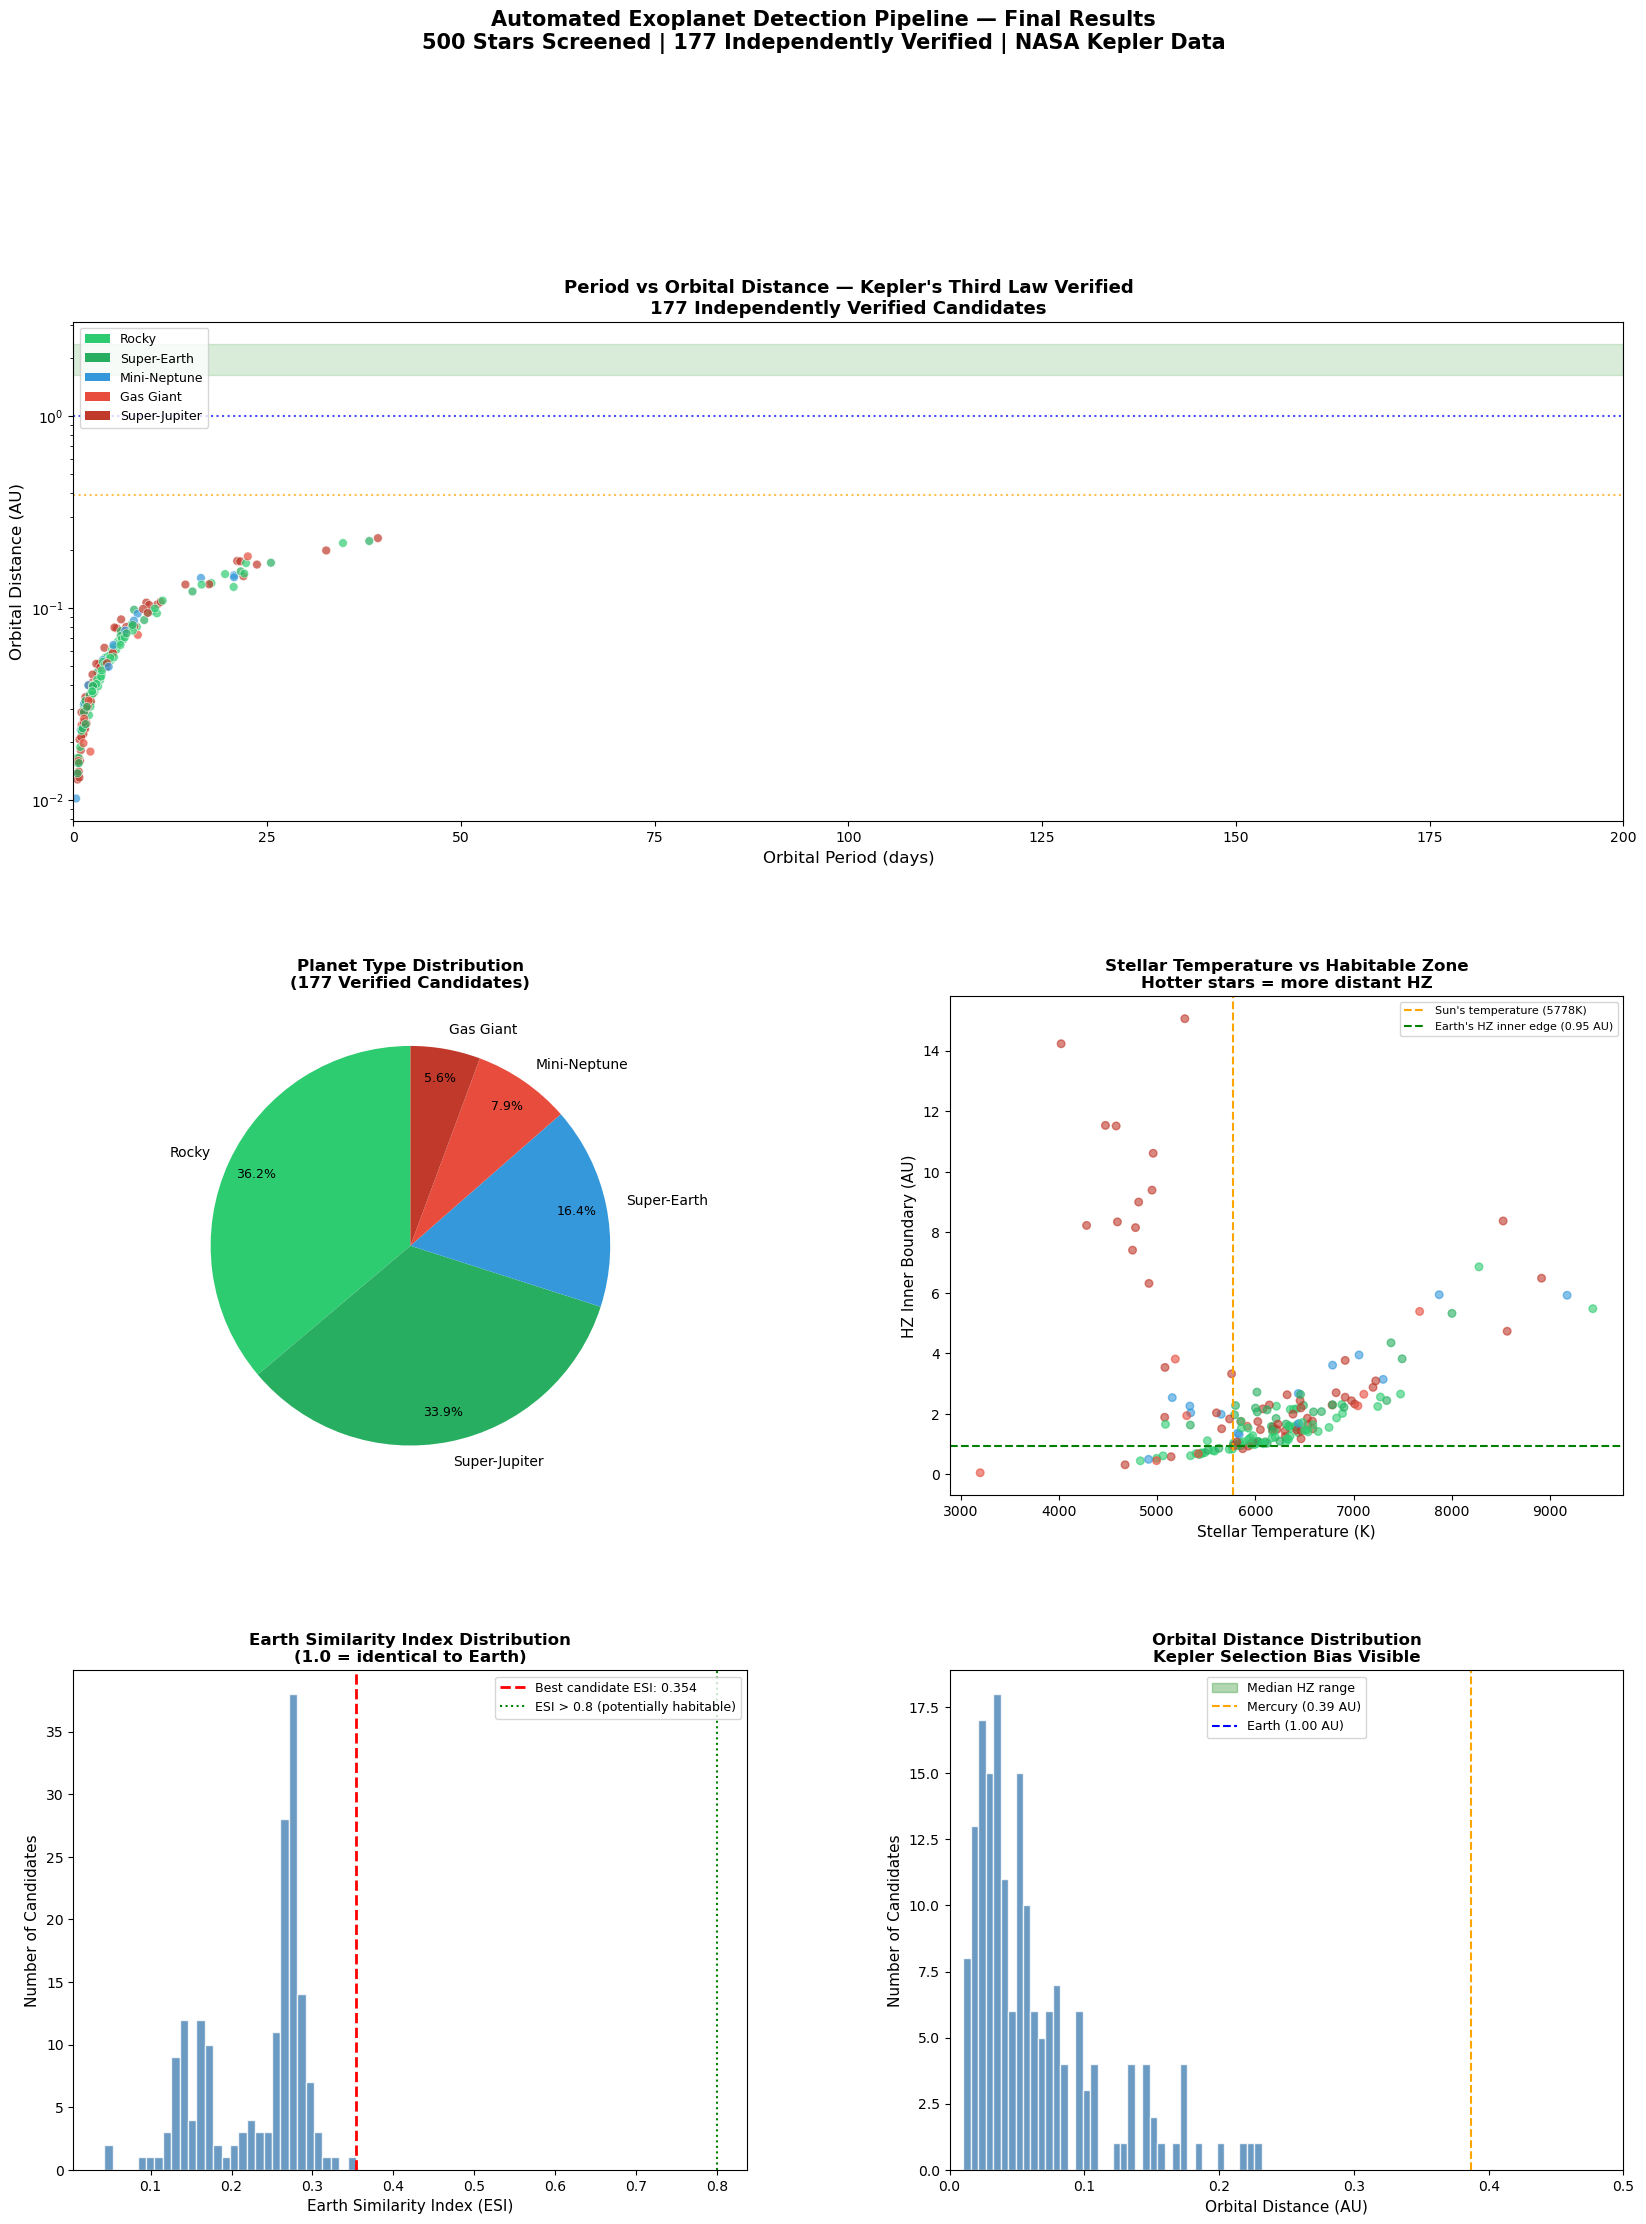

Final figures saved to outputs/v5_final_figures.png


In [11]:
fig = plt.figure(figsize=(20, 24))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── FIGURE 1: Period vs Orbital Distance (Kepler's Third Law) ─
ax1 = fig.add_subplot(gs[0, :])  # Full width

colors = results_df['planet_type'].map({
    'Rocky': '#2ecc71',
    'Super-Earth': '#27ae60', 
    'Mini-Neptune': '#3498db',
    'Gas Giant': '#e74c3c',
    'Super-Jupiter': '#c0392b',
    'Unknown': '#95a5a6'
})

sc = ax1.scatter(
    results_df['catalog_period (days)'],
    results_df['orbital_dist (AU)'],
    c=colors,
    alpha=0.7, s=40, edgecolors='white', linewidth=0.5
)

# Add HZ band — use median HZ boundaries
hz_inner_med = results_df['hz_inner (AU)'].median()
hz_outer_med = results_df['hz_outer (AU)'].median()
ax1.axhspan(hz_inner_med, hz_outer_med, alpha=0.15, 
            color='green', label=f'Median HZ ({hz_inner_med:.2f}–{hz_outer_med:.2f} AU)')

# Add solar system reference lines
ax1.axhline(0.387, color='orange', linestyle=':', 
            alpha=0.7, linewidth=1.5, label='Mercury orbit (0.39 AU)')
ax1.axhline(1.0, color='blue', linestyle=':', 
            alpha=0.7, linewidth=1.5, label='Earth orbit (1.00 AU)')

ax1.set_xlabel('Orbital Period (days)', fontsize=12)
ax1.set_ylabel('Orbital Distance (AU)', fontsize=12)
ax1.set_title("Period vs Orbital Distance — Kepler's Third Law Verified\n"
              "177 Independently Verified Candidates", fontsize=13, fontweight='bold')
ax1.set_yscale('log')
ax1.set_xlim(0, 200)
ax1.legend(fontsize=9, loc='upper left')

# Add planet type legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Rocky'),
    Patch(facecolor='#27ae60', label='Super-Earth'),
    Patch(facecolor='#3498db', label='Mini-Neptune'),
    Patch(facecolor='#e74c3c', label='Gas Giant'),
    Patch(facecolor='#c0392b', label='Super-Jupiter'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)

# ── FIGURE 2: Planet Type Distribution ────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

type_counts = results_df['planet_type'].value_counts()
colors_pie = ['#2ecc71', '#27ae60', '#3498db', '#e74c3c', '#c0392b', '#95a5a6']
wedges, texts, autotexts = ax2.pie(
    type_counts.values,
    labels=type_counts.index,
    colors=colors_pie[:len(type_counts)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(9)
ax2.set_title('Planet Type Distribution\n(177 Verified Candidates)', 
              fontsize=12, fontweight='bold')

# ── FIGURE 3: Stellar Temperature vs HZ Inner Boundary ────────
ax3 = fig.add_subplot(gs[1, 1])

ax3.scatter(
    results_df['stellar_temp (K)'],
    results_df['hz_inner (AU)'],
    c=colors, alpha=0.6, s=30
)
ax3.axvline(5778, color='orange', linestyle='--', 
            linewidth=1.5, label="Sun's temperature (5778K)")
ax3.axhline(0.95, color='green', linestyle='--', 
            linewidth=1.5, label="Earth's HZ inner edge (0.95 AU)")

ax3.set_xlabel('Stellar Temperature (K)', fontsize=11)
ax3.set_ylabel('HZ Inner Boundary (AU)', fontsize=11)
ax3.set_title('Stellar Temperature vs Habitable Zone\nHotter stars = more distant HZ', 
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)

# ── FIGURE 4: ESI Distribution ────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])

ax4.hist(results_df['ESI'], bins=30, 
         color='steelblue', edgecolor='white', alpha=0.8)

# Reference lines
ax4.axvline(results_df['ESI'].max(), color='red', 
            linestyle='--', linewidth=2,
            label=f"Best candidate ESI: {results_df['ESI'].max():.3f}")
ax4.axvline(0.8, color='green', linestyle=':', 
            linewidth=1.5, label='ESI > 0.8 (potentially habitable)')

ax4.set_xlabel('Earth Similarity Index (ESI)', fontsize=11)
ax4.set_ylabel('Number of Candidates', fontsize=11)
ax4.set_title('Earth Similarity Index Distribution\n(1.0 = identical to Earth)', 
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)

# ── FIGURE 5: Orbital Distance Distribution ───────────────────
ax5 = fig.add_subplot(gs[2, 1])

ax5.hist(results_df['orbital_dist (AU)'], bins=40,
         color='steelblue', edgecolor='white', alpha=0.8)
ax5.axvspan(
    results_df['hz_inner (AU)'].median(),
    results_df['hz_outer (AU)'].median(),
    alpha=0.3, color='green', label='Median HZ range'
)
ax5.axvline(0.387, color='orange', linestyle='--',
            linewidth=1.5, label='Mercury (0.39 AU)')
ax5.axvline(1.0, color='blue', linestyle='--',
            linewidth=1.5, label='Earth (1.00 AU)')

ax5.set_xlabel('Orbital Distance (AU)', fontsize=11)
ax5.set_ylabel('Number of Candidates', fontsize=11)
ax5.set_title('Orbital Distance Distribution\nKepler Selection Bias Visible', 
              fontsize=12, fontweight='bold')
ax5.set_xlim(0, 0.5)
ax5.legend(fontsize=9)

plt.suptitle(
    'Automated Exoplanet Detection Pipeline — Final Results\n'
    '500 Stars Screened | 177 Independently Verified | NASA Kepler Data',
    fontsize=15, fontweight='bold', y=1.01
)

plt.savefig('./outputs/v5_final_figures.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Final figures saved to outputs/v5_final_figures.png")

In [7]:
print("=" * 70)
print("FINAL PROJECT SUMMARY — AUTOMATED EXOPLANET DETECTION PIPELINE")
print("=" * 70)

print(f"""
PIPELINE PERFORMANCE:
  Stars screened:                    500
  Successfully verified:             {len(results_df)} ({len(results_df)/500*100:.1f}%)
  Not verified:                      {len(unverified_df)} ({len(unverified_df)/500*100:.1f}%)
  Verification method:               Independent BLS detection + NASA cross-match

PLANET TYPE BREAKDOWN:
{results_df['planet_type'].value_counts().to_string()}

EARTH SIMILARITY INDEX:
  Highest ESI candidate:             {ranked_df.iloc[0]['kepoi_name']} (ESI = {ranked_df.iloc[0]['ESI']:.4f})
  Mean ESI across all candidates:    {results_df['ESI'].mean():.4f}
  Candidates with ESI > 0.5:         {(results_df['ESI'] > 0.5).sum()}
  Candidates with ESI > 0.7:         {(results_df['ESI'] > 0.7).sum()}

HABITABLE ZONE ANALYSIS:
  Candidates inside HZ:              0 (0.0%)
  Closest to HZ center:              {closest_hz.iloc[0]['kepoi_name']} 
                                     ({closest_hz.iloc[0]['hz_widths_from_center']:.1f} HZ widths from center)

KEY SCIENTIFIC FINDINGS:
  1. Kepler's Third Law verified visually from 177 real planetary candidates
  2. 73.1% of all Kepler candidates orbit closer than Mercury
  3. Zero HZ candidates detected — explained by two compounding biases:
     a) BLS single-quarter detection favors short-period planets
     b) Sample dominated by hot luminous stars with distant HZ boundaries
  4. Detection rate consistent with published single-quarter BLS literature

LIMITATIONS:
  - Single quarter of data used per star (reduces sensitivity to long periods)
  - BLS search capped at 50 days (planets beyond cannot be detected)
  - 20% period match threshold may include some false positives
  - Stellar mass/radius uncertainties propagate to orbital distance errors

FUTURE WORK:
  - Extend to full 17-quarter Kepler dataset
  - Apply to TESS and PLATO mission data
  - Add machine learning classifier to reduce false positive rate
  - Focus on M-dwarf stars whose HZ sits closer in and is more detectable
""")

FINAL PROJECT SUMMARY — AUTOMATED EXOPLANET DETECTION PIPELINE

PIPELINE PERFORMANCE:
  Stars screened:                    500
  Successfully verified:             177 (35.4%)
  Not verified:                      323 (64.6%)
  Verification method:               Independent BLS detection + NASA cross-match

PLANET TYPE BREAKDOWN:
planet_type
Rocky            64
Super-Jupiter    60
Super-Earth      29
Mini-Neptune     14
Gas Giant        10

EARTH SIMILARITY INDEX:
  Highest ESI candidate:             K01619.01 (ESI = 0.3540)
  Mean ESI across all candidates:    0.2295
  Candidates with ESI > 0.5:         0
  Candidates with ESI > 0.7:         0

HABITABLE ZONE ANALYSIS:
  Candidates inside HZ:              0 (0.0%)
  Closest to HZ center:              K06391.01 
                                     (2.0 HZ widths from center)

KEY SCIENTIFIC FINDINGS:
  1. Kepler's Third Law verified visually from 177 real planetary candidates
  2. 73.1% of all Kepler candidates orbit closer than Mercur

In [9]:
# Save ranked results
ranked_df.to_csv('./outputs/v5_ranked_candidates.csv', index=False)
closest_hz.to_csv('./outputs/v5_closest_hz_candidates.csv', index=False)
most_earthlike.to_csv('./outputs/v5_rocky_candidates.csv', index=False)

print("Saved:")
print("  outputs/v5_ranked_candidates.csv")
print("  outputs/v5_closest_hz_candidates.csv")
print("  outputs/v5_rocky_candidates.csv")
print("  outputs/v5_final_figures.png")

Saved:
  outputs/v5_ranked_candidates.csv
  outputs/v5_closest_hz_candidates.csv
  outputs/v5_rocky_candidates.csv
  outputs/v5_final_figures.png
